<a href="https://colab.research.google.com/github/gowriv05/Python_Project_Socialmedia_engagement/blob/main/Python_project_socialmedia_engagement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Social Media Engagement Analytics Using Python

## Project Overview

This project analyzes social media engagement data using Python, Pandas, NumPy, Matplotlib, Seaborn, and Plotly.

The analysis includes data loading, data cleaning, exploratory data analysis, statistical analysis, data visualization, and generating meaningful insights from the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


## 1. Data Import and Setup

The social media engagement dataset is imported using Pandas. The first five rows are displayed to verify that the dataset has been loaded correctly.

In [2]:
df = pd.read_csv("social_media_engagement_5000.csv")
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [3]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


## 2. Dataset Structure and Data Types

In this section, the structure of the dataset is examined using shape, columns, info(), and dtypes. This helps us understand the number of records, available variables, and data types of each column.

In [4]:
df.shape

(5000, 19)

In [5]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [7]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
count,5000.000000,4850.000000,5000.000000,4850.000000,4850.000000,4850.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,393698.224800,0.964356
std,26090.370121,14.912381,260646.957267,5789.819252,869.537889,579.615158,2308.096459,28844.939104,230927.884535,5.318029
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5068.500000,760.000000,498.000000,2017.750000,24988.250000,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.000000,4034.500000,49934.500000,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,15115.000000,2256.000000,1501.000000,6020.250000,74662.250000,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,799533.000000,191.504348


In [8]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


## 3. Date Conversion

The 'posted_at' column is currently stored as an object data type. It is converted to datetime format so that date-based analysis can be performed.

In [9]:
df['posted_at']=pd.to_datetime(df['posted_at'],format="%d-%m-%Y",errors='coerce')
df['posted_at'].dtype

dtype('<M8[ns]')

In [10]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


## 4. Data Cleaning

### Checking Missing Values

Missing values are identified using 'isnull()' and 'isna()'. This helps determine which columns contain missing data before selecting an appropriate method to handle them.

In [11]:
print("Missing using isnull():")
df.isnull().sum()

Missing using isnull():


,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [12]:
missing_percentage=(df.isnull().sum()/len(df))*100
missing_percentage=missing_percentage[missing_percentage>0]
missing_percentage

,0
age,3.0
gender,3.0
likes,3.0
comments,3.0
shares,3.0
sentiment,3.0


### Handling Missing Values

The columns age, gender, comments, shares, and sentiment contain 150 missing values each, which represents 3% of the total 5,000 records.

Since the missing values are less than 5%, the affected rows are removed using dropna().

In [13]:
df=df.dropna(subset=['age','gender','likes','comments','shares','sentiment'])
print("Dataset after removing null values:")
df.shape

Dataset after removing null values:


(4162, 19)

### Verification of Missing Values

After removing the rows containing missing values in the selected columns, the missing values are checked again to confirm that the cleaning process was successful.

In [14]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


## 5. Duplicate Handling

Duplicate records are checked using duplicated(). The dataset does not contain duplicate rows, so no records need to be removed for duplication.

In [15]:
df.duplicated().sum()

np.int64(0)

### Checking Unrealistic Engagement Values

The likes, comments, and shares columns are checked for negative values because engagement counts cannot be negative.

In [16]:
(df['likes']<0).sum()

np.int64(0)

In [17]:
(df['comments']<0).sum()

np.int64(0)

In [18]:
(df['shares']<0).sum()

np.int64(0)

### Creating Hashtag Count

The hashtags column contains hashtags separated by spaces. A new feature called hashtag_count is created to represent the number of hashtags used in each post.

In [19]:
df['hashtag_count']=df['hashtags'].fillna('').apply(lambda x:len(str(x).split()))
df[['hashtags','hashtag_count']].head()


,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


## 3. Data Exploration

### Categorical Data Distribution

The categorical columns are explored using `unique()`, `nunique()`, and `value_counts()` to identify the unique categories and their frequency distribution.


In [20]:
print("Gender:")
print("Unique values:",df['gender'].unique())
print("Number of unique values:",df['gender'].nunique())
print(df['gender'].value_counts())

print("\nPost Type:")
print("Unique values:",df['post_type'].unique())
print("Number of unique values:",df['post_type'].nunique())
print(df['post_type'].value_counts())

print("\nPost Category:")
print("Unique values:",df['post_category'].unique())
print("Number of unique values:",df['post_category'].nunique())
print(df['post_category'].value_counts())

print("\nSentiment:")
print("Unique values:",df['sentiment'].unique())
print("Number of unique values:",df['sentiment'].nunique())
print(df['sentiment'].value_counts())

Gender:
Unique values: ['Female' 'Male' 'Other']
Number of unique values: 3
gender
Male      1477
Female    1354
Other     1331
Name: count, dtype: int64

Post Type:
Unique values: ['image' 'reel' 'text' 'video']
Number of unique values: 4
post_type
reel     1065
image    1044
text     1035
video    1018
Name: count, dtype: int64

Post Category:
Unique values: ['fitness' 'food' 'tech' 'travel' 'lifestyle' 'education' 'music'
 'fashion']
Number of unique values: 8
post_category
fitness      578
tech         566
education    515
music        512
lifestyle    510
fashion      500
travel       499
food         482
Name: count, dtype: int64

Sentiment:
Unique values: ['negative' 'positive' 'neutral']
Number of unique values: 3
sentiment
positive    2018
neutral     1317
negative     827
Name: count, dtype: int64


### Correlation Matrix

A correlation matrix is created for the numeric columns to examine the relationships between numerical variables. The correlation values range from -1 to +1, where values closer to +1 indicate a positive relationship and values closer to -1 indicate a negative relationship.


In [21]:
numeric_columns=df.select_dtypes(include='number')
correlation_matrix=numeric_columns.corr()
correlation_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.016610,0.014552,0.035584,-0.026360,0.010624,-0.021526,0.009995,0.017189,-0.000632,-0.025727
age,-0.016610,1.000000,-0.009944,-0.037100,-0.011132,0.012808,0.008402,0.014665,-0.027001,0.009695,0.002347
post_id,0.014552,-0.009944,1.000000,0.013925,-0.014432,0.005733,0.023821,-0.010847,-0.003109,0.009431,0.008239
likes,0.035584,-0.037100,0.013925,1.000000,-0.016923,0.004428,0.000579,-0.000887,-0.009989,0.093356,0.002346
comments,-0.026360,-0.011132,-0.014432,-0.016923,1.000000,0.008826,-0.019330,-0.009390,-0.013134,0.002415,-0.018602
shares,0.010624,0.012808,0.005733,0.004428,0.008826,1.000000,0.018717,0.003362,-0.004357,0.024374,0.015174
watch_time_sec,-0.021526,0.008402,0.023821,0.000579,-0.019330,0.018717,1.000000,-0.015654,0.001116,-0.000670,-0.027836
impression_count,0.009995,0.014665,-0.010847,-0.000887,-0.009390,0.003362,-0.015654,1.000000,-0.019981,-0.230212,-0.013261
follower_count,0.017189,-0.027001,-0.003109,-0.009989,-0.013134,-0.004357,0.001116,-0.019981,1.000000,0.002218,0.017634
engagement_rate,-0.000632,0.009695,0.009431,0.093356,0.002415,0.024374,-0.000670,-0.230212,0.002218,1.000000,0.008057


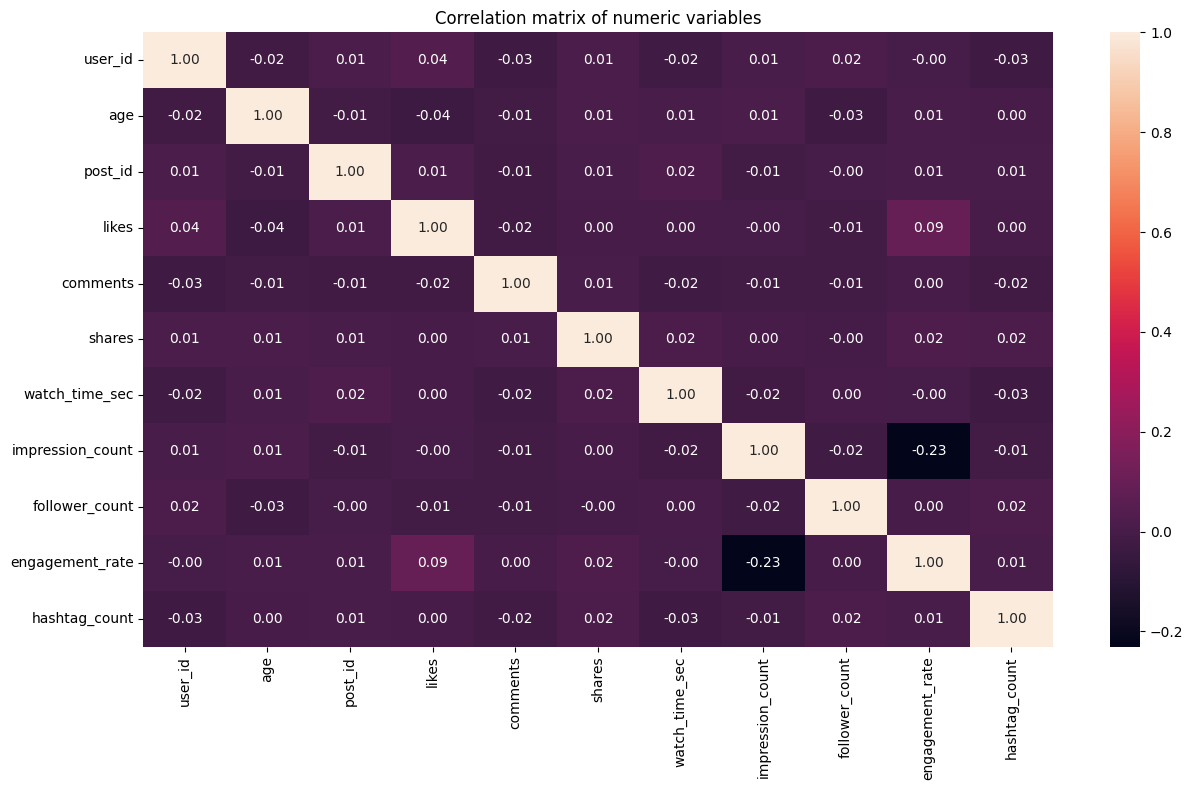

In [22]:
plt.figure(figsize=(13,8))
sns.heatmap(correlation_matrix,annot=True,fmt='.2f')
plt.title('Correlation matrix of numeric variables')
plt.tight_layout()
plt.show()

In this heatmap, numerical columns shows the correlation, where here impression count and engagement rate has strong negative correlation.

In [23]:
avg_likes_by_post_type=df.groupby('post_type')['likes'].mean()
avg_likes_by_post_type

,likes
post_type,
image,10078.105364
reel,10046.336150
text,9999.017391
video,10104.700393


### Groupby Analysis: Average Impressions by Country

The average number of impressions is calculated for each country using groupby(). This helps examine how the average reach of posts varies across countries.


In [24]:
avg_impression_by_country=df.groupby('country')['impression_count'].mean()
avg_impression_by_country

,impression_count
country,
Australia,47462.187648
Brazil,49606.840000
Canada,48475.293981
France,51330.009501
Germany,48648.537084
India,52689.146341
Japan,50202.933673
UAE,48703.443099
UK,51303.958937


## 4. Data Wrangling

### Combining DataFrames

The project uses a single dataset and does not require combining multiple DataFrames. Therefore, merge(), concat(), and join() are not required for this analysis.


In [25]:
df.shape

(4162, 20)

### Creating Engagement Score

An engagement score is created by combining likes, comments, and shares. This provides a simple measure of the total engagement received by each post.


In [26]:
df['engagement_score']=(df['likes']+df['comments']+df['shares'])
df[['likes','comments','shares','engagement_score']].head()

,likes,comments,shares,engagement_score
0,7011.0,354.0,1157.0,8522.0
1,11750.0,2606.0,1807.0,16163.0
2,4862.0,344.0,955.0,6161.0
3,5350.0,1083.0,1049.0,7482.0
4,12682.0,2735.0,1300.0,16717.0


In [27]:
print('hashtag_count' in df.columns)

True


### Groupby Summary by Post Type

The data is grouped by post type to summarize engagement metrics for different types of posts. The average likes, comments, shares, and engagement score are calculated for each post type.


In [28]:
post_type_summary=df.groupby('post_type')[['likes','comments','shares','engagement_score']].mean()
post_type_summary

,likes,comments,shares,engagement_score
post_type,,,,
image,10078.105364,1516.591954,1010.930077,12605.627395
reel,10046.336150,1511.224413,980.596244,12538.156808
text,9999.017391,1490.102415,1024.442512,12513.562319
video,10104.700393,1491.938114,981.619843,12578.258350


### Groupby Summary by Country

The data is grouped by country to compare average engagement metrics across different countries.


In [29]:
country_summary=df.groupby('country')[['likes','comments','shares','engagement_score']].mean()
country_summary

,likes,comments,shares,engagement_score
country,,,,
Australia,10323.147268,1504.277910,1029.610451,12857.035629
Brazil,9802.903529,1457.461176,992.456471,12252.821176
Canada,10061.203704,1566.511574,989.620370,12617.335648
France,10188.909739,1482.123515,1041.741093,12712.774347
Germany,10258.104859,1539.997442,982.496164,12780.598465
India,9979.669623,1517.893570,1048.598670,12546.161863
Japan,10145.594388,1531.994898,961.619898,12639.209184
UAE,10229.653753,1552.324455,977.709443,12759.687651
UK,9694.599034,1441.391304,978.623188,12114.613527


In [57]:
highest_engagement_country=df.groupby('country')['engagement_rate'].mean()
highest_engagement_country

,engagement_rate
country,
Australia,1.462492
Brazil,1.637193
Canada,0.927467
France,1.250086
Germany,0.817767
India,0.690853
Japan,0.794976
UAE,1.116916
UK,0.872840


### Groupby Summary by Sentiment

The data is grouped by sentiment to compare engagement metrics across positive, negative, and neutral posts.


In [30]:
sentiment_summary=df.groupby('sentiment')[['likes','comments','shares','engagement_score']].mean()
sentiment_summary

,likes,comments,shares,engagement_score
sentiment,,,,
negative,10116.993954,1519.695284,997.540508,12634.229746
neutral,9937.506454,1531.094153,990.652240,12459.252847
positive,10110.013875,1477.000000,1005.786918,12592.800793


In [31]:
post_category_summary=df.groupby('post_category')[['likes','comments','shares','engagement_score']].mean()
post_category_summary

,likes,comments,shares,engagement_score
post_category,,,,
education,10144.662136,1475.023301,986.310680,12605.996117
fashion,9640.584000,1524.544000,975.802000,12140.930000
fitness,9892.226644,1492.906574,1043.828720,12428.961938
food,10006.317427,1516.317427,1009.819502,12532.454357
lifestyle,10213.866667,1468.052941,974.580392,12656.500000
music,10310.062500,1561.720703,1030.910156,12902.693359
tech,10163.498233,1484.560071,992.712014,12640.770318
travel,10081.260521,1502.168337,975.308617,12558.737475


## 5. Statistical Analysis

Descriptive statistical analysis is performed on the likes, comments, shares, watch_time_sec, engagement_rate, and follower_count columns. Mean, median, mode, standard deviation, variance, and percentiles are calculated to understand the central tendency and spread of the data.


In [32]:
stats_columns=['likes','comments','shares','watch_time_sec','engagement_rate','follower_count']
stats_df=df[stats_columns]
stats_df.head()

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0,7011.0,354.0,1157.0,5726,0.190862,81734
1,11750.0,2606.0,1807.0,5947,0.201493,5963
2,4862.0,344.0,955.0,6946,0.137345,501783
3,5350.0,1083.0,1049.0,229,0.106195,480212
4,12682.0,2735.0,1300.0,4798,2.777372,383936


### Mean, Median and Mode

The mean, median, and mode are calculated to understand the central tendency of the selected numerical variables. The mean represents the average value, the median represents the middle value, and the mode represents the most frequently occurring value.


In [33]:
mean_values=stats_df.mean()
median_values=stats_df.median()
mode_values=stats_df.mode().iloc[0]
print("Mean:")
print(mean_values)
print("\nMedian:")
print(median_values)
print("\nMode:")
print(mode_values)

Mean:
likes               10056.813551
comments             1502.600913
shares                999.359202
watch_time_sec       3988.097549
engagement_rate         1.015154
follower_count     394707.644402
dtype: float64

Median:
likes               10016.000000
comments             1505.500000
shares               1007.000000
watch_time_sec       4010.500000
engagement_rate         0.253054
follower_count     390905.500000
dtype: float64

Mode:
likes               13536.000000
comments             1806.000000
shares                138.000000
watch_time_sec       4360.000000
engagement_rate         0.006363
follower_count     497502.000000
Name: 0, dtype: float64


### Standard Deviation and Variance

Standard deviation and variance are calculated to measure the spread of the numerical data. A higher value indicates greater variability in the corresponding variable.


In [34]:
std_values=stats_df.std()
variance_values=stats_df.var()
print("Standard Deviation:")
print(std_values)
print("\nVariance:")
print(variance_values)

Standard Deviation:
likes                5792.668485
comments              869.743640
shares                580.989352
watch_time_sec       2312.095707
engagement_rate         5.748086
follower_count     231315.725822
dtype: float64

Variance:
likes              3.355501e+07
comments           7.564540e+05
shares             3.375486e+05
watch_time_sec     5.345787e+06
engagement_rate    3.304049e+01
follower_count     5.350697e+10
dtype: float64


### Percentile Analysis

The 25th, 50th, and 75th percentiles are calculated to understand the distribution of the selected numerical variables. These percentiles help identify the lower, middle, and upper portions of the data.


In [35]:
percentiles=stats_df.quantile([0.25,0.50,0.75])
percentiles

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,4991.5,764.25,488.25,1966.50,0.144968,195597.75
0.50,10016.0,1505.50,1007.00,4010.50,0.253054,390905.50
0.75,15056.5,2258.00,1499.00,5990.75,0.502043,589908.50


### Optional: Skewness and Kurtosis

Skewness and kurtosis are calculated as additional measures to understand the shape and distribution of the selected numerical variables.


In [36]:
skewness_values=stats_df.skew()
kurtosis_values=stats_df.kurt()
print("Skewness:")
print(skewness_values)
print("\nKurtosis:")
print(kurtosis_values)

Skewness:
likes               0.001169
comments            0.002039
shares             -0.009028
watch_time_sec     -0.006841
engagement_rate    17.751400
follower_count      0.037005
dtype: float64

Kurtosis:
likes               -1.205249
comments            -1.200768
shares              -1.208517
watch_time_sec      -1.208625
engagement_rate    423.834703
follower_count      -1.185274
dtype: float64


In [37]:
statistical_summary = pd.DataFrame({
    'Mean': stats_df.mean(),
    'Median': stats_df.median(),
    'Mode': stats_df.mode().iloc[0],
    'Standard Deviation': stats_df.std(),
    'Variance': stats_df.var(),
    '25th Percentile': stats_df.quantile(0.25),
    '50th Percentile': stats_df.quantile(0.50),
    '75th Percentile': stats_df.quantile(0.75),
    'Skewness': stats_df.skew(),
    'Kurtosis': stats_df.kurt()
})

statistical_summary

,Mean,Median,Mode,Standard Deviation,Variance,25th Percentile,50th Percentile,75th Percentile,Skewness,Kurtosis
likes,10056.813551,10016.000000,13536.000000,5792.668485,3.355501e+07,4991.500000,10016.000000,15056.500000,0.001169,-1.205249
comments,1502.600913,1505.500000,1806.000000,869.743640,7.564540e+05,764.250000,1505.500000,2258.000000,0.002039,-1.200768
shares,999.359202,1007.000000,138.000000,580.989352,3.375486e+05,488.250000,1007.000000,1499.000000,-0.009028,-1.208517
watch_time_sec,3988.097549,4010.500000,4360.000000,2312.095707,5.345787e+06,1966.500000,4010.500000,5990.750000,-0.006841,-1.208625
engagement_rate,1.015154,0.253054,0.006363,5.748086,3.304049e+01,0.144968,0.253054,0.502043,17.751400,423.834703
follower_count,394707.644402,390905.500000,497502.000000,231315.725822,5.350697e+10,195597.750000,390905.500000,589908.500000,0.037005,-1.185274


## 6. Data Visualization

Data visualization is used to identify patterns, relationships, distributions, and trends in the social media engagement dataset. Matplotlib and Seaborn are used for statistical and categorical visualizations, while Plotly is used to create an interactive visualization.


### 6.1 Scatter Plot: Likes vs Impressions

A scatter plot is used to examine the relationship between likes and impressions.

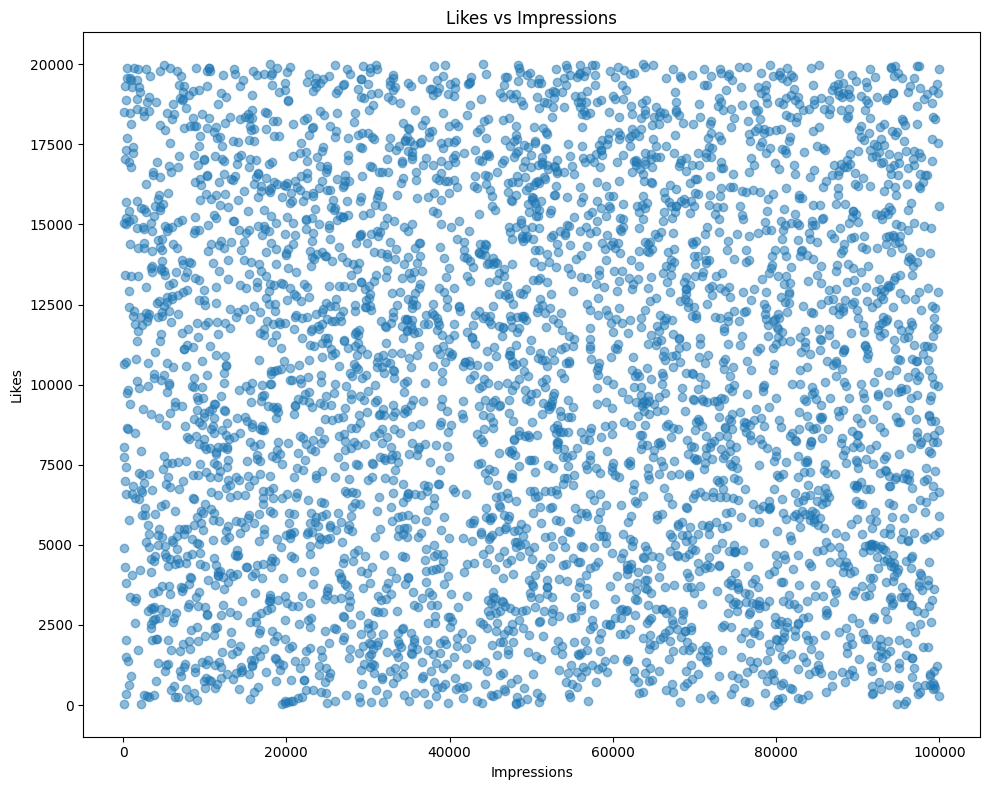

In [38]:
plt.figure(figsize=(10,8))
plt.scatter(df['impression_count'],df['likes'],alpha=0.5)
plt.xlabel('Impressions')
plt.ylabel('Likes')
plt.title('Likes vs Impressions')
plt.tight_layout()
plt.show()

### Insight

The scatter plot shows the relationship between likes and impression_count. In general, posts with higher impressions can receive higher numbers of likes, although the relationship is not perfectly linear. Some observations show unusually high engagement compared with their impressions.

### 6.2 Line Chart: Daily Engagement Trend

A line chart is used to visualize the daily trend in engagement over time.

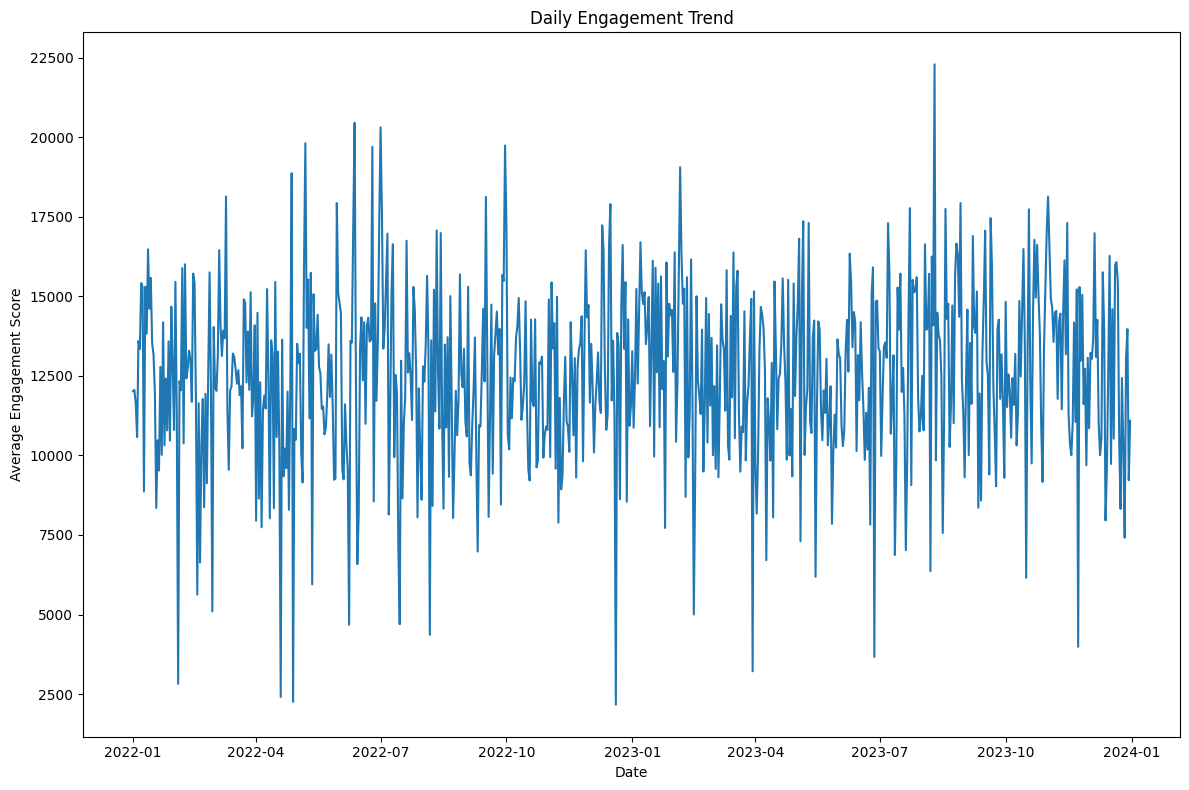

In [39]:
daily_engagement=(df.groupby('posted_at')['engagement_score'].mean().reset_index().sort_values('posted_at'))
plt.figure(figsize=(12,8))
plt.plot(daily_engagement['posted_at'],daily_engagement['engagement_score'])
plt.xlabel('Date')
plt.ylabel('Average Engagement Score')
plt.title('Daily Engagement Trend')
plt.tight_layout()
plt.show()

### Insight

The daily engagement trend shows how social media engagement changes over time. The values fluctuate across different dates, indicating that engagement is not constant and may vary depending on the content and audience response.

### 6.3 Bar Chart: Posts by Category

A bar chart is used to compare the number of posts across different content categories.

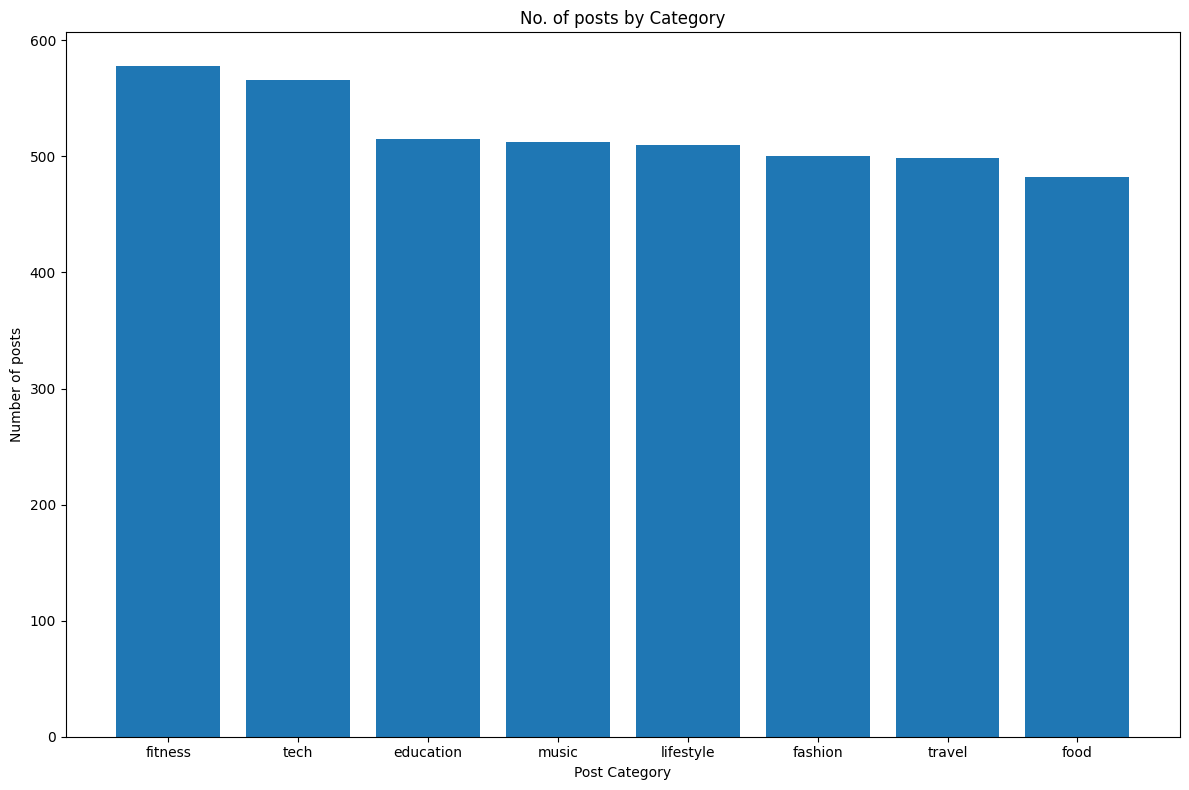

In [40]:
category_counts=df['post_category'].value_counts()
plt.figure(figsize=(12,8))
plt.bar(category_counts.index,category_counts.values)
plt.xlabel('Post Category')
plt.ylabel('Number of posts')
plt.title('No. of posts by Category')
plt.tight_layout()
plt.show()


### Insight

The category distribution shows the number of posts published across different content categories. Fitness was one of the prominent categories in the dataset, indicating a relatively high volume of content in this category.

### 6.4 Pie Chart: Gender Distribution

A pie chart is used to show the distribution of users across different gender categories.

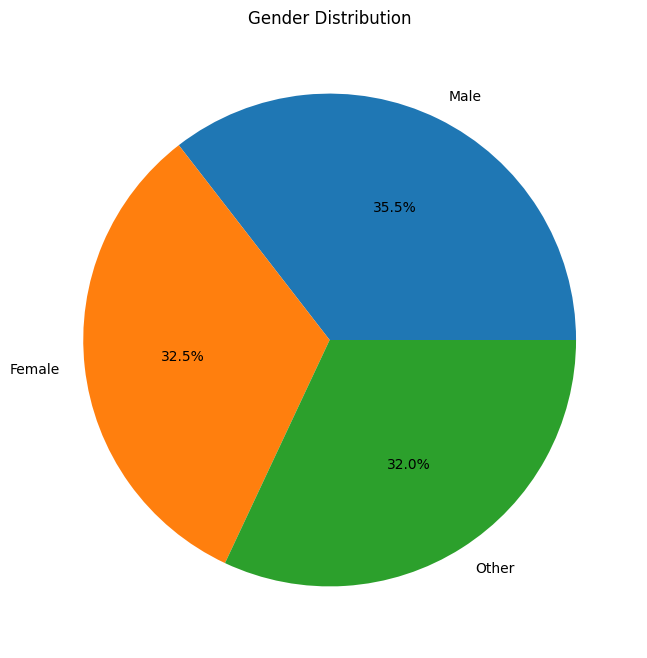

In [41]:
gender_counts=df['gender'].value_counts()
plt.figure(figsize=(12,8))
plt.pie(gender_counts.values,labels=gender_counts.index,autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()


### Insight

The pie chart shows the distribution of posts across different gender groups. It shows that male users are slightly higher than female and other users.

### 6.5 Histogram: Age Distribution

A histogram is used to understand the distribution of user ages in the dataset.

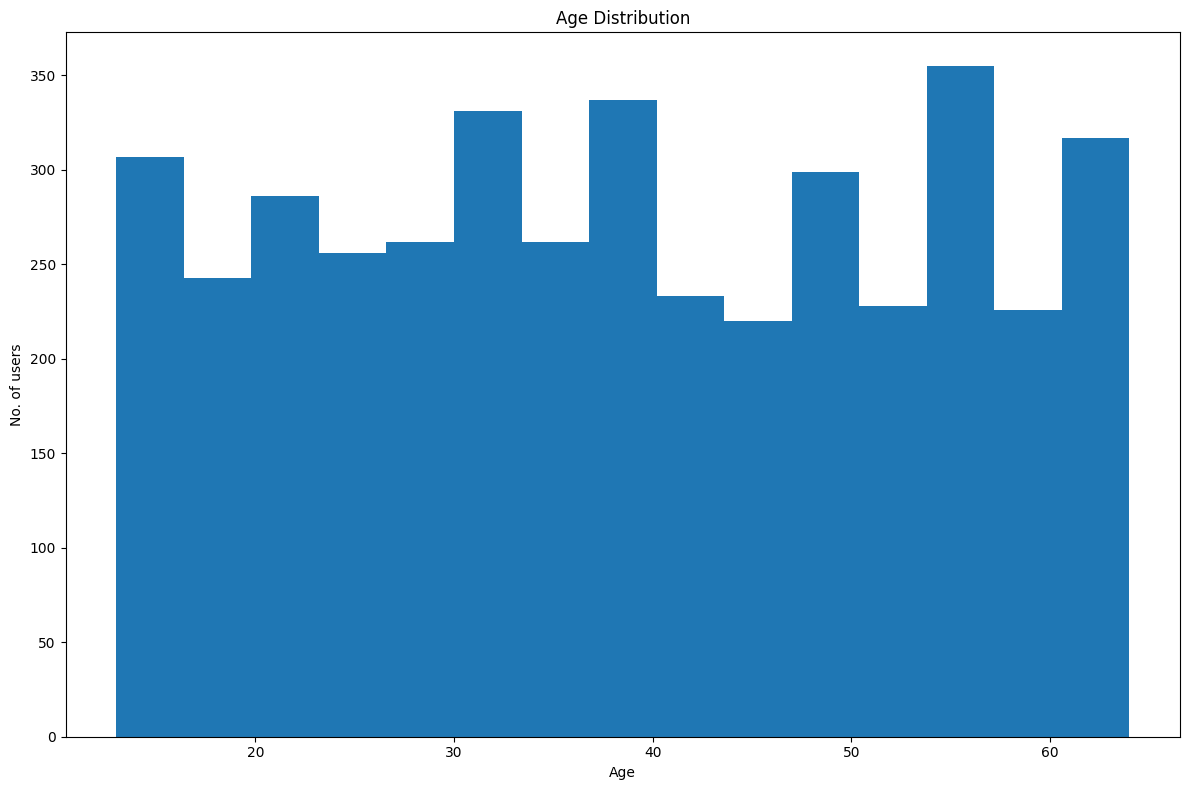

In [42]:
plt.figure(figsize=(12,8))
plt.hist(df['age'],bins=15)
plt.xlabel('Age')
plt.ylabel('No. of users')
plt.title('Age Distribution')
plt.tight_layout()
plt.show()

### Insight

The histogram shows the distribution of users across different age groups. The 52-55 age group shows relatively high representation in the dataset.

### 6.6 Box Plot: Engagement Rate

A box plot is used to examine the distribution of engagement rate and identify possible outliers.

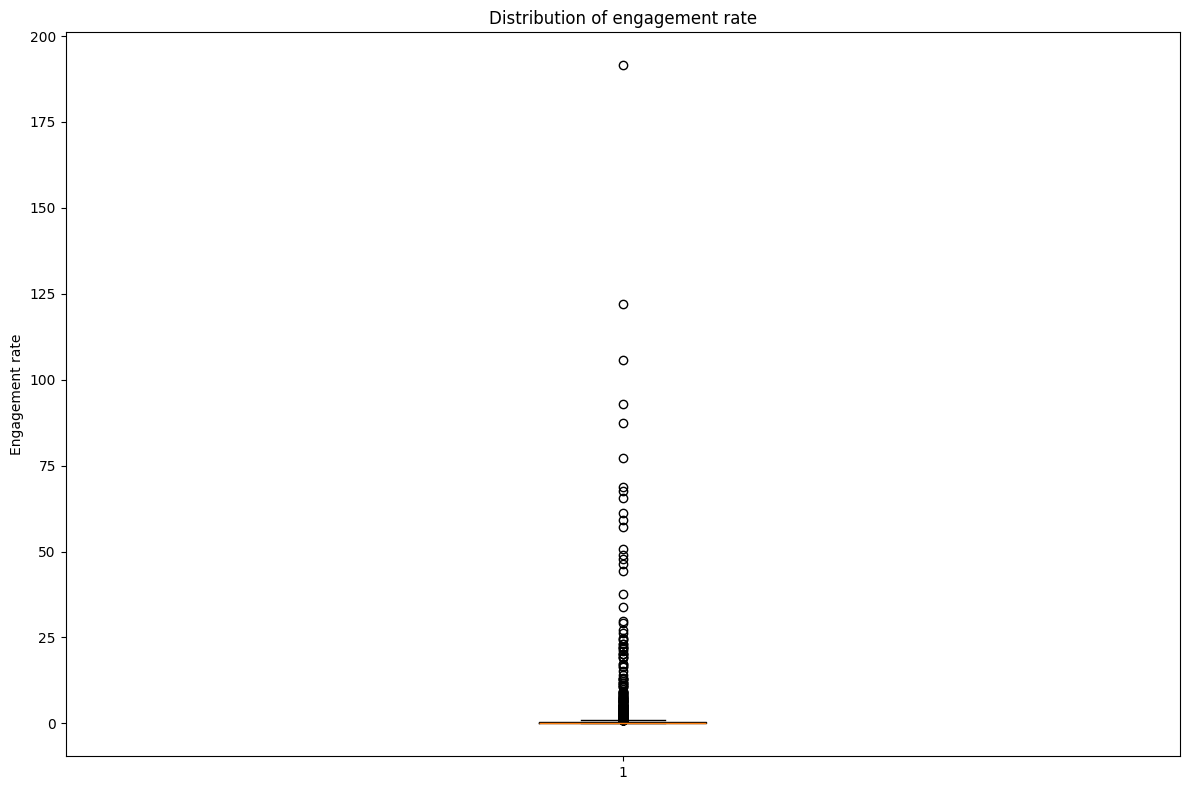

In [43]:
plt.figure(figsize=(12,8))
plt.boxplot(df['engagement_rate'])
plt.ylabel('Engagement rate')
plt.title('Distribution of engagement rate')
plt.tight_layout()
plt.show()

In [44]:
Q1=df['engagement_rate'].quantile(0.25)
Q3=df['engagement_rate'].quantile(0.75)
IQR=Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("Lower Bound:",lower_bound)
print("Upper Bound:",upper_bound)

Q1: 0.144967656
Q3: 0.50204296325
IQR: 0.35707530725
Lower Bound: -0.390645304875
Upper Bound: 1.037655924125


In [45]:
outliers = df[
    (df[['likes', 'comments', 'shares']] < lower_bound) |
    (df[['likes', 'comments', 'shares']] > upper_bound)
]

len(outliers)

4162

In [46]:
df['engagement_rate'].skew()

np.float64(17.751400273504064)

In [47]:
df['engagement_rate'].kurt()

np.float64(423.83470301743716)

### Outlier Detection

Outliers in engagement_rate were identified using the IQR method. The calculated upper bound was 1.038, and 484 observations were identified as potential outliers.

The engagement_rate distribution is highly right-skewed, with a skewness of 17.75 and high kurtosis of 423.83. This indicates the presence of extreme engagement values.

These observations were not removed automatically because an outlier does not necessarily represent an incorrect data entry. High engagement values may represent posts with unusually strong performance. Therefore, the outliers were retained for further analysis.

### 6.7 Count Plot: Post Type

A Seaborn count plot is used to compare the number of posts for each post type.

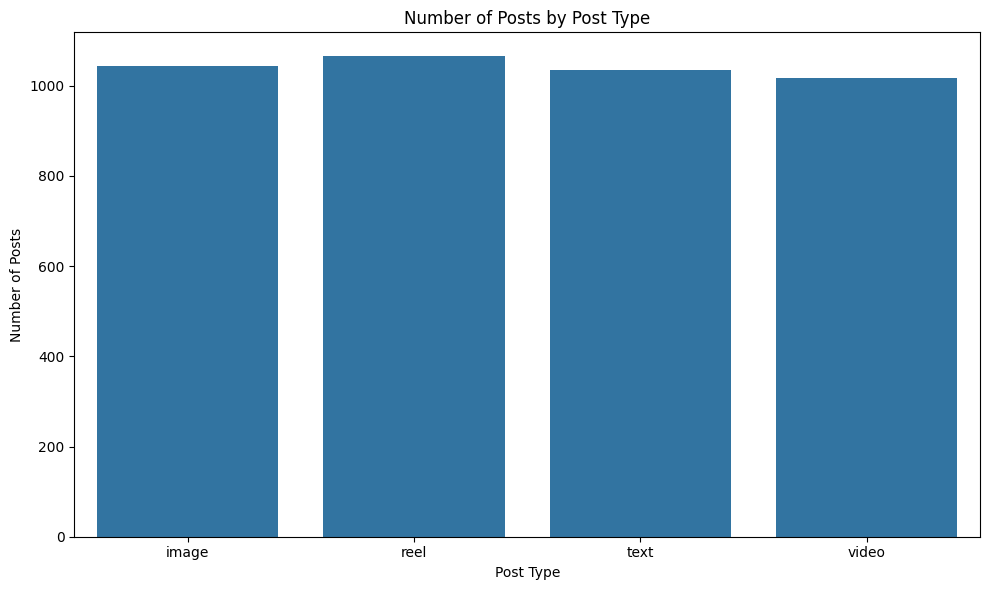

In [48]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='post_type')
plt.xlabel('Post Type')
plt.ylabel('Number of Posts')
plt.title('Number of Posts by Post Type')
plt.tight_layout()
plt.show()

### Insight

The count plot shows the distribution of different post types. Reel posts have a strong presence in the dataset and show high engagement compared with other post types.

### 6.8 Bar Plot: Average Likes by Category

A Seaborn bar plot is used to compare the average number of likes received by different content categories.

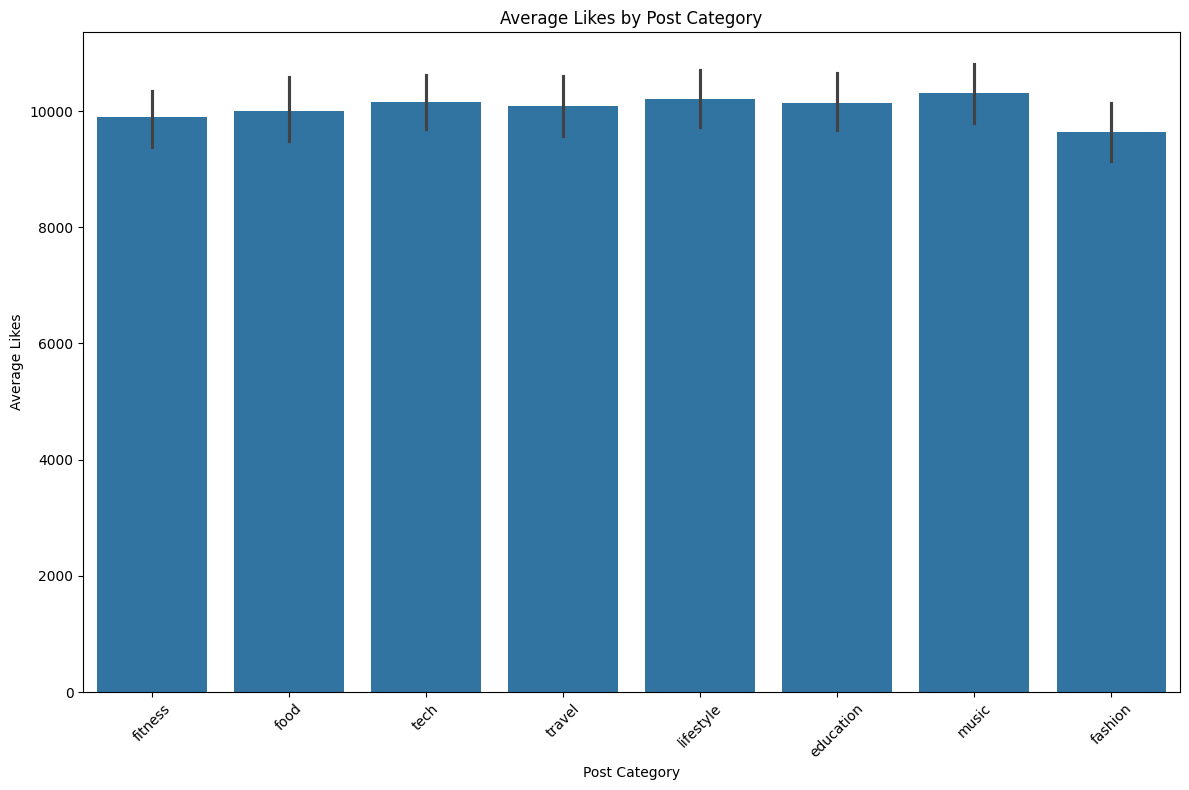

In [49]:
plt.figure(figsize=(12,8))
sns.barplot(data=df,x='post_category',y='likes')
plt.xlabel('Post Category')
plt.ylabel('Average Likes')
plt.title('Average Likes by Post Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

The comparison of average likes across categories shows that audience response varies by content category. Music category receive relatively higher engagement from users.

### 6.9 Violin Plot: Followers vs Sentiment

A violin plot is used to compare the distribution of follower counts across different sentiment categories.

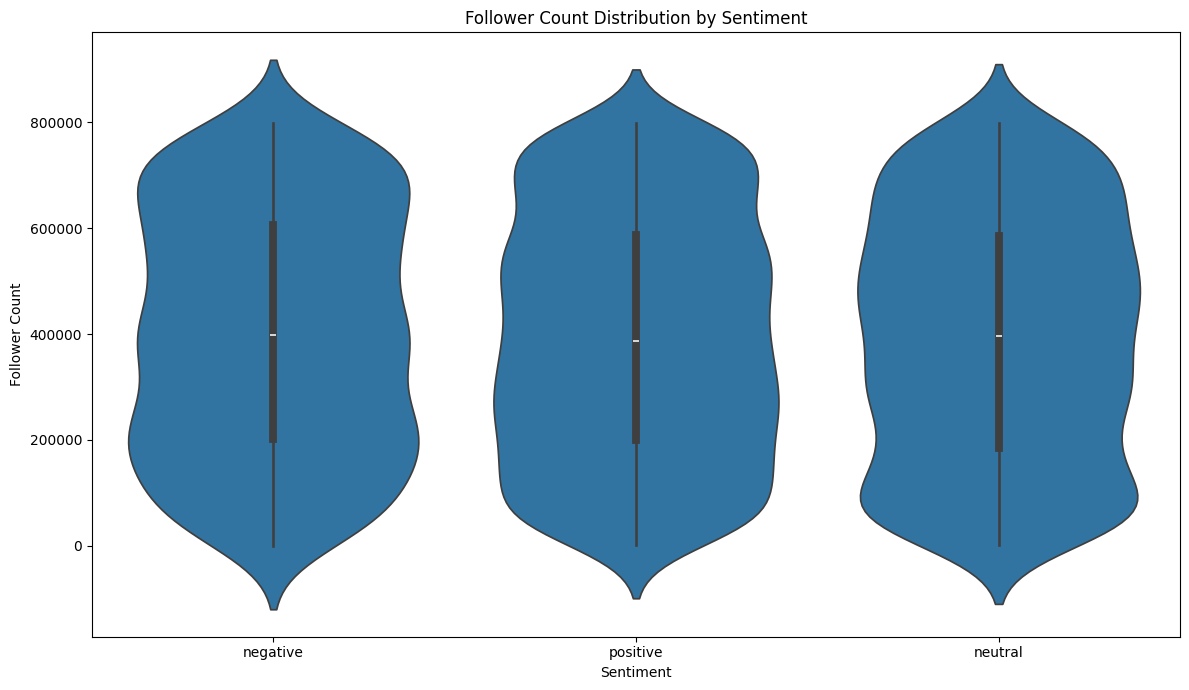

In [50]:
plt.figure(figsize=(12,7))
sns.violinplot(data=df,x='sentiment',y='follower_count')
plt.xlabel('Sentiment')
plt.ylabel('Follower Count')
plt.title('Follower Count Distribution by Sentiment')
plt.tight_layout()
plt.show()

### Insight

The violin plot shows the distribution of engagement_rate across different sentiment groups. Negative sentiment has a slightly higher average engagement rate.

### 6.10 Pair Plot: Numeric Features

A pair plot is used to visualize relationships and distributions among selected numerical variables.

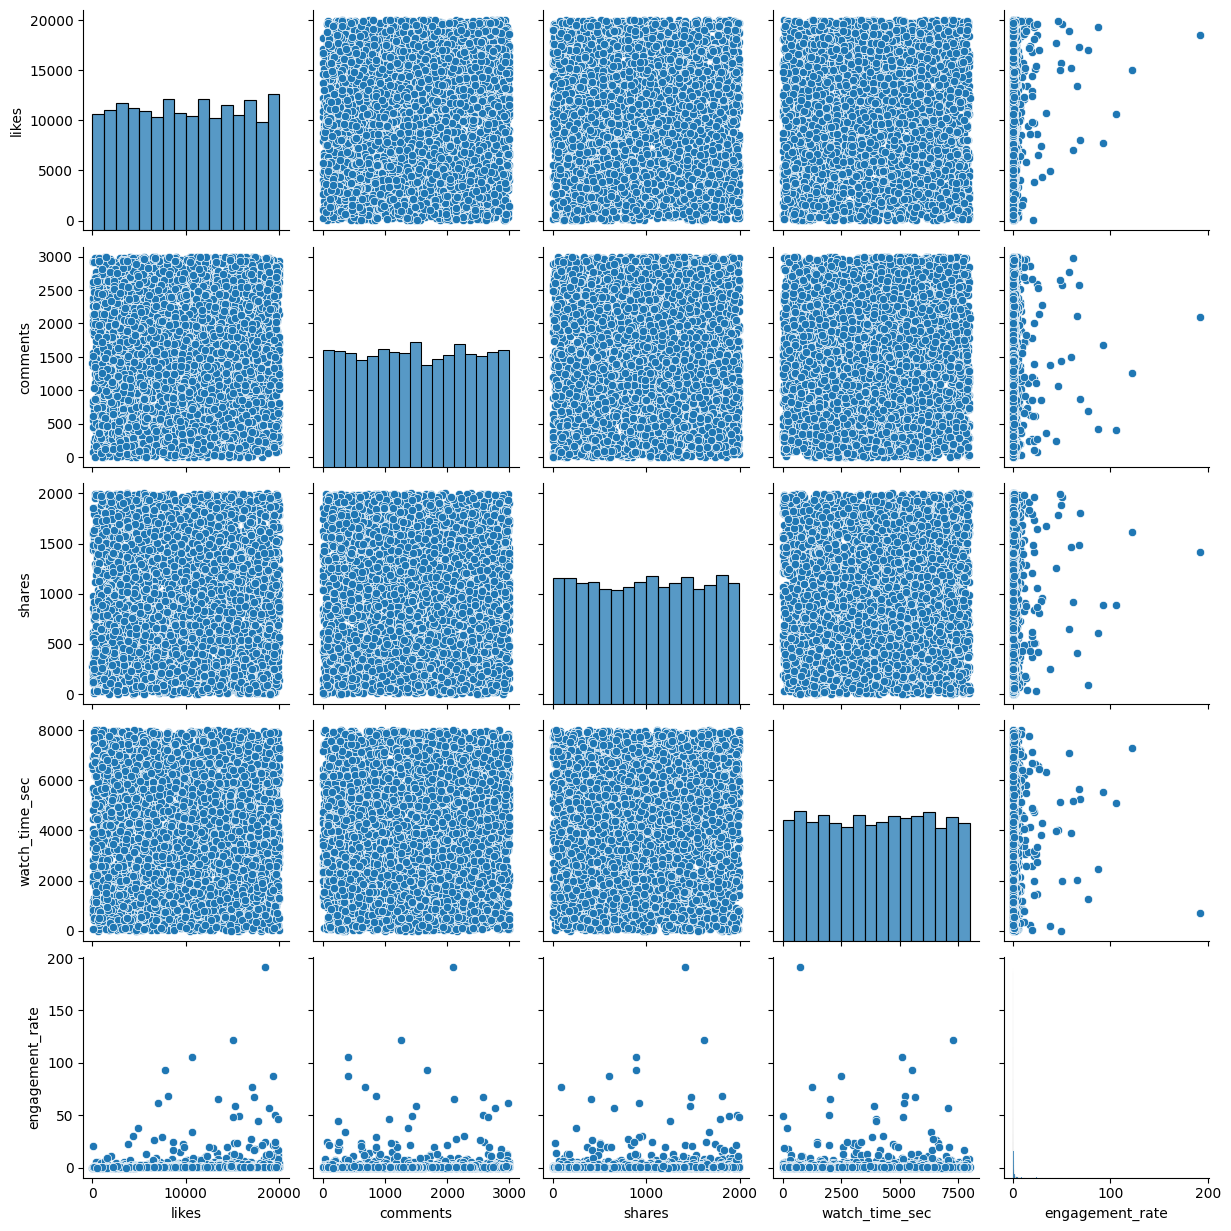

In [51]:
pair_data=df[['likes','comments','shares','watch_time_sec','engagement_rate']]
sns.pairplot(pair_data)
plt.show()

### Insight

The visualization shows how engagement varies across different sentiment groups and follower levels. The distribution indicates that follower count alone does not completely explain engagement, as engagement varies within each group.

### 6.11 Heatmap: Correlation Matrix

A heatmap is used to visualize the correlation between numerical variables. It helps identify positive and negative relationships between the variables.

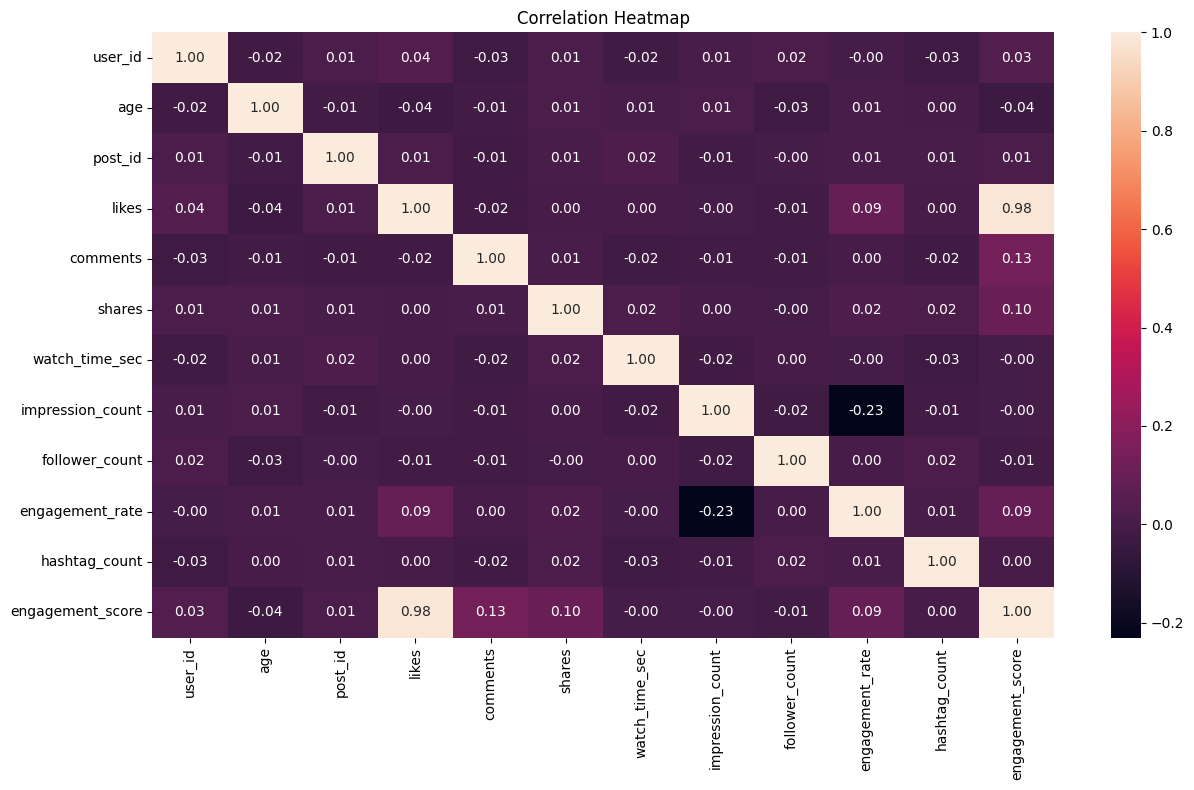

In [52]:
correlation_matrix=df.select_dtypes(include='number').corr()
plt.figure(figsize=(13,8))
sns.heatmap(correlation_matrix,annot=True,fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In this heatmap, numerical columns shows the correlation, where here impression count and engagement rate has strong negative correlation.

### 6.12 Swarm Plot: Engagement vs Device

A swarm plot is used to examine the distribution of engagement scores across different device types.

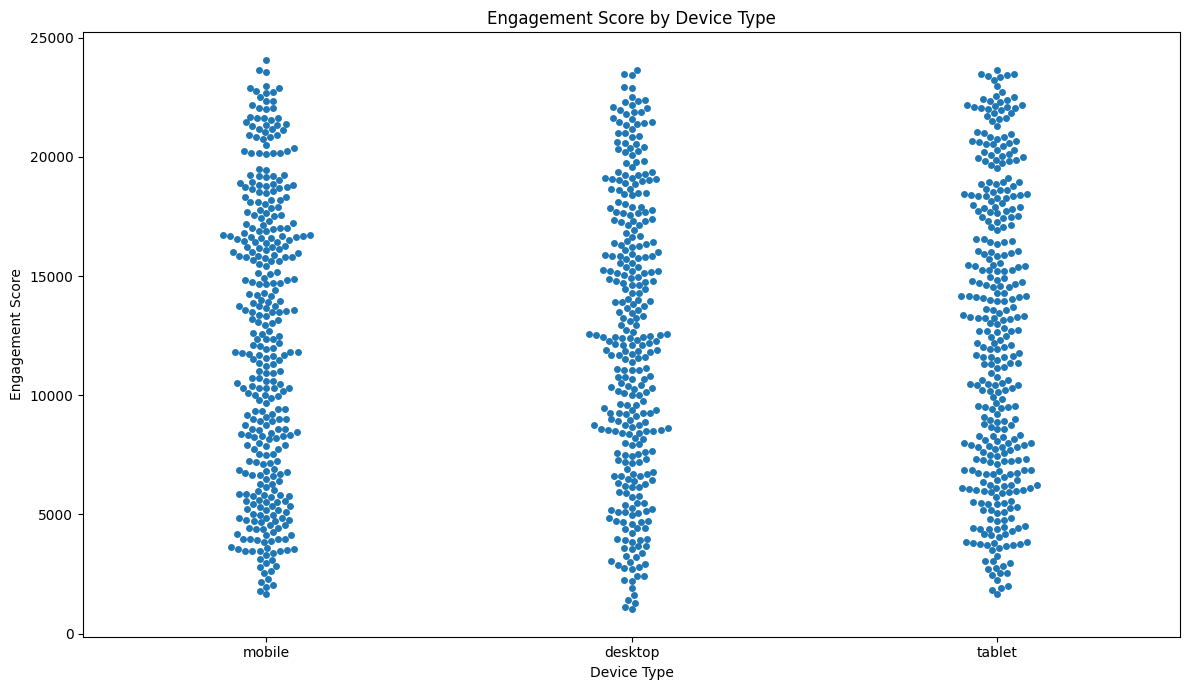

In [53]:
plt.figure(figsize=(12,7))
sns.swarmplot(data=df.sample(min(1000,len(df)),random_state=42),x='device_type',y='engagement_score')
plt.xlabel('Device Type')
plt.ylabel('Engagement Score')
plt.title('Engagement Score by Device Type')
plt.tight_layout()
plt.show()

This indicates substantial content consumption through mobile devices in the dataset.

### 6.13 Interactive Bar Chart Using Plotly

An interactive bar chart is created using Plotly to compare average engagement scores across post types. The interactive chart allows users to explore the values by hovering over the bars.

In [59]:
plotly_data=(df.groupby('post_type')['engagement_score'].mean().reset_index())
fig=px.bar(plotly_data,x='post_type',y='engagement_score',title='Average Engagement Score by Post Type',labels={
        'post_type': 'Post Type','engagement_score': 'Average Engagement Score'})
fig.show()
fig.write_html("average_engagement_by_post_type.html")

### Performance Difference for Verified Accounts

The 'is_verified' column indicates whether an account is verified or not. We compare the average likes, comments, shares, and engagement rate between verified and non-verified accounts to understand whether there is a difference in performance.

In [55]:
verified_performance=df.groupby('is_verified')[['likes','comments','shares','engagement_rate']].mean()
verified_performance

,likes,comments,shares,engagement_rate
is_verified,,,,
False,10066.711692,1508.115323,997.983983,1.001748
True,9967.682692,1452.944712,1011.742788,1.135869


## 7. Final Insights

### Content Performance

* Among the post types, Video posts have the highest average likes in the dataset.
* Music has the highest average likes among the content categories.
* Brazil has the highest average engagement rate among the countries in the dataset.

### User Trends

* Age has a very weak relationship with engagement rate in this dataset, so no strong age-based engagement pattern is observed.
* The comparison between verified and non-verified accounts shows some differences in performance. Verified accounts have slightly higher average shares and engagement rate, while non-verified accounts have higher average likes and comments. The average engagement rate is 1.1359 for verified accounts compared with 1.0017 for non-verified accounts, showing a small difference in engagement rate between the two groups.

### Behavioral Insights

* Mobile users have the highest average watch time among the available device types.
* The dataset contains dates but does not contain the time of day for each post. Therefore, the best time of day for impressions cannot be determined from the available data.

### Sentiment Analysis

* Negative sentiment posts have the highest average engagement rate among the three sentiment categories in this dataset.
* Neutral posts have a slightly lower average engagement rate than negative posts, while positive posts have the lowest average engagement rate among the three categories.